#**Pokémon Type Classification using Deep Learning**

### **Introduction:**
This notebook focuses on classifying Pokémon based on their images using a deep learning model. The workflow involves:

1. **Data Collection & Preprocessing:**  
   - Downloading a Pokémon image dataset.
   - Loading a Pokémon metadata CSV file.
   - Preprocessing images (resizing, normalising) and labels (one-hot encoding Pokémon types).

2. **Building the Dataset:**  
   - Extracting image metadata.
   - Merging Pokémon data with image file paths. You can find the [Pokemon data](https://docs.google.com/spreadsheets/d/1PEYifvGweFm4QUjTGmyZ2D70lRkxOOxdeaakAdNSCx8/edit?usp=sharing) and [images](https://www.kaggle.com/datasets/kvpratama/pokemon-images-dataset) here.
   - Splitting the dataset into training and testing sets.

3. **Implementing a Neural Network:**  
   - Constructing a two-layer neural network with a hidden layer.
   - Defining activation functions (e.g. Sigmoid & Softmax).
   - Implementing forward propagation, cost computation, and backpropagation.

4. **Training & Evaluating the Model:**  
   - Optimizing the network using gradient descent.
   - Evaluating the model's performance with accuracy metrics.
   - Visualising loss curves and classification accuracy.

5. **Making Predictions:**  
   - Testing the trained model on unseen Pokémon images.
   - Displaying results with true vs. predicted labels.

By the end of this notebook, the model should be able to classify Pokémon types with some accuracy, providing insights into deep learning techniques for image classification.


In [ ]:
import os
import re
import numpy as np
import pandas as pd
from os import listdir
from os.path import isfile, join
from PIL import Image

from IPython.display import clear_output
import matplotlib.pyplot as plt

# Data Preparation

This script downloads, processes, and prepares a Pokémon image dataset for machine learning. Here's a concise summary:

1. **Download Dataset**: It retrieves a Pokémon image dataset from Kaggle using `kagglehub` and defines the image directory.
2. **Load & Preprocess CSV**: It fetches a Pokémon CSV file from a URL, renames columns, enforces integer types for the Pokédex number, converts Pokémon types to lowercase, and maps 18 predefined types to indices.
3. **Extract Image Metadata**: It lists image filenames in the dataset, extracts Pokédex numbers using regex, and stores file paths and numbers in a DataFrame.
4. **Merge DataFrames**: It merges the Pokémon metadata with the image paths using the Pokédex number as a key.
5. **Preprocess Images & Labels**:
   - Loads and resizes images to **64×64 pixels**.
   - Normalizes pixel values to **[0,1]**.
   - Converts Pokémon primary types to **one-hot encoded vectors**.
   - Stores images and labels in NumPy arrays (`X` for images, `y` for labels).

The processed data is now ready for use in machine learning models.

In [ ]:

# -------------------------------
# 1. Download the image dataset via kagglehub
# -------------------------------
import kagglehub

# Download the latest version of the Pokémon image dataset.
dataset_path = kagglehub.dataset_download("kvpratama/pokemon-images-dataset")
print("Path to dataset files:", dataset_path)

# The images are in a folder called "pokemon" inside the dataset.
IMG_DIR = os.path.join(dataset_path, "pokemon/pokemon")

# -------------------------------
# 2. Load Pokémon CSV from URL and Preprocess Columns
# -------------------------------
csv_url = ("https://gist.githubusercontent.com/armgilles/"
           "194bcff35001e7eb53a2a8b441e8b2c6/raw/"
           "92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv")
pokemon_df = pd.read_csv(csv_url)

# Rename columns:
# - Rename '#' to 'pokedex #' (to match the image filenames)
# - Rename 'Type 1' to 'type1'
pokemon_df.rename(columns={'#': 'pokedex #', 'Type 1': 'type1'}, inplace=True)

# Force the pokedex number to be an integer.
pokemon_df['pokedex #'] = pokemon_df['pokedex #'].astype(int)

# Convert primary type to lowercase.
pokemon_df['type1'] = pokemon_df['type1'].str.lower()

# Define the 18 target types.
types_list = ['grass', 'fire', 'water', 'bug', 'normal', 'poison', 'electric',
              'ground', 'fairy', 'fighting', 'psychic', 'rock', 'ghost', 'ice',
              'dragon', 'dark', 'steel', 'flying']

# Create a mapping from type string to index.
type_to_index = {tp: i for i, tp in enumerate(types_list)}

# -------------------------------
# 3. List image files from IMG_DIR and extract pokedex numbers
# -------------------------------
all_files = [f for f in listdir(IMG_DIR) if isfile(join(IMG_DIR, f))]
print(f"Found {len(all_files)} files in {IMG_DIR}")

img_paths = []
pokedex_numbers = []
for fname in all_files:
    # Use regex to extract digits at the beginning of the filename.
    # For example, for "115-mega.jpg" this returns "115"
    match = re.match(r'^(\d+)', fname)
    if match is None:
        # If there is no match, skip this file.
        continue
    number = match.group(1)
    img_paths.append(join(IMG_DIR, fname))
    pokedex_numbers.append(int(number))


df_img = pd.DataFrame({'pokedex #': pokedex_numbers, 'image_path': img_paths})
print("Image DataFrame shape:", df_img.shape)
print(df_img.head())

# -------------------------------
# 4. Merge the CSV data with the image paths
# -------------------------------
data = pd.merge(pokemon_df, df_img, on='pokedex #')
print("Merged data shape:", data.shape)
print(data.head())

# Extract Pokémon names from the merged DataFrame.
names = data["Name"].values

# -------------------------------
# 5. Load and Preprocess Images & Labels
# -------------------------------
# Resize images to 64x64 for faster training.
IMG_SIZE = (64, 64)

def load_and_preprocess_image(img_path, size=IMG_SIZE):
    """
    Load an image from img_path, convert to RGB, resize to 'size',
    and normalise pixel values to [0, 1].
    """
    img = Image.open(img_path).convert('RGB')
    img = img.resize(size)
    img_array = np.array(img, dtype=np.float32) / 255.0
    return img_array

X_list = []
y_list = []

for idx, row in data.iterrows():
    img_path = row['image_path']
    # Load the image and flatten it.
    img_array = load_and_preprocess_image(img_path)
    X_list.append(img_array.flatten())

    # Get the Pokémon primary type.
    label_str = row['type1']
    # Skip samples with types not in our target list.
    if label_str not in type_to_index:
        continue
    label_idx = type_to_index[label_str]
    one_hot = np.zeros(len(types_list))
    one_hot[label_idx] = 1
    y_list.append(one_hot)

# Convert lists into numpy arrays.
X = np.array(X_list)  # Shape: (num_samples, 64*64*3)
y = np.array(y_list)  # Shape: (num_samples, 18)

print("X shape:", X.shape)
print("y shape:", y.shape)

100%|██████████| 70.9M/70.9M [00:03<00:00, 19.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kvpratama/pokemon-images-dataset/versions/2
Found 819 files in /root/.cache/kagglehub/datasets/kvpratama/pokemon-images-dataset/versions/2/pokemon/pokemon
Image DataFrame shape: (819, 2)
   pokedex #                                         image_path
0        586  /root/.cache/kagglehub/datasets/kvpratama/poke...
1        345  /root/.cache/kagglehub/datasets/kvpratama/poke...
2        351  /root/.cache/kagglehub/datasets/kvpratama/poke...
3        264  /root/.cache/kagglehub/datasets/kvpratama/poke...
4         91  /root/.cache/kagglehub/datasets/kvpratama/poke...
Merged data shape: (1005, 14)
   pokedex #                   Name  type1  Type 2  Total  HP  Attack  \
0          1              Bulbasaur  grass  Poison    318  45      49   
1          2                Ivysaur  grass  Poison    405  60      62   
2          3               Venusaur  grass  Poison    525  80      82   
3          3               Venusaur  grass  Poison  

# Train-Test Split

This code **splits the dataset** into training and testing sets using **80% training and 20% testing**. It uses `train_test_split` from `sklearn.model_selection` to divide the **features (X)**, **labels (y)**, and **Pokémon names** while ensuring a reproducible split with `random_state=42`. After splitting, it prints the dataset's shape before and after the split for verification.

In [ ]:
# -------------------------------
# 4. Split Data into Training and Testing Sets
# -------------------------------
from sklearn.model_selection import train_test_split

test_size = 0.2 # Split the data (80% training, 20% testing)

# Split features, labels, and names together.
X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X, y, names, test_size=test_size, random_state=42)

# Print verification output
print("\nData Split Summary:")
print(f"Original dataset shape: {X.shape}, Labels: {y.shape}")
print(f"Training set shape:     {X_train.shape}, Labels: {y_train.shape}")
print(f"Testing set shape:      {X_test.shape}, Labels: {y_test.shape}")
print(f"\nSplit ratio: {int((1-test_size)*100)}% train / {int(test_size*100)}% test")
print(f"Random state: 42 (ensures reproducible split)")


Data Split Summary:
Original dataset shape: (1005, 12288), Labels: (1005, 18)
Training set shape:     (804, 12288), Labels: (804, 18)
Testing set shape:      (201, 12288), Labels: (201, 18)

Split ratio: 80% train / 20% test
Random state: 42 (ensures reproducible split)


# Neural Network Implementation
This section defines and implements a **two-layer neural network** for classifying Pokémon based on their images. The key components include:

1. **Activation Functions**:
   - Implements **sigmoid** (for the hidden layer) and **softmax** (for output classification). These two are provided for you. You are welcome to implement your own activation functions, but it is not required.

2. **Parameter Initialization**:
   - Initialises weights and biases for a neural network with **one hidden layer**.

   - Computes **hidden layer activations** and **final output probabilities**.

   - Uses **categorical cross-entropy** to evaluate model performance.

   - Computes gradients for **weights and biases** using the chain rule.

   - Updates network parameters using **gradient descent**.

You are required to **complete missing code** in forward propagation, cost computation, backpropagation, and parameter updates to train the model successfully.

**NOTE:** Your model cannot be trained or used for prediction until these functions are complete.

In [ ]:
# -------------------------------
# 5. Define the Neural Network
# -------------------------------

# We use a simple two-layer network with one hidden layer.

# Activation functions - use provided or implement any of your own activation function here
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def softmax(Z):
    eZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return eZ / np.sum(eZ, axis=0, keepdims=True)

def initialize_parameters(input_size, hidden_size, output_size):
    np.random.seed(42)
    W1 = np.random.randn(hidden_size, input_size) * 0.01
    b1 = np.zeros((hidden_size, 1))
    W2 = np.random.randn(output_size, hidden_size) * 0.01
    b2 = np.zeros((output_size, 1))
    return W1, b1, W2, b2


def forward_propagation(X, W1, b1, W2, b2):
    """
    Performs the forward propagation through a two-layer neural network.

    Arguments:
        X -- input data of shape (m, input_size)
        W1 -- weights matrix for the hidden layer (hidden_size, input_size)
        b1 -- bias vector for the hidden layer (hidden_size, 1)
        W2 -- weights matrix for the output layer (output_size, hidden_size)
        b2 -- bias vector for the output layer (output_size, 1)

    Returns:
        Z1 -- linear combination at the hidden layer
        A1 -- activation from the hidden layer using the sigmoid function
        Z2 -- linear combination at the output layer
        A2 -- activation from the output layer using the softmax function
    """
    m = X.shape[0]

    # Use np.dot() to multiply W1 with the transpose of X and add b1.
    # Make sure that the dimensions are compatible.
    Z1 = np.dot(W1, X.T) + b1

    # Use the provided sigmoid function.
    A1 = sigmoid(Z1)

    # Multiply W2 with A1 and add b2. Ensure that broadcasting is handled correctly.
    Z2 = np.dot(W2, A1) + b2

    # The softmax function should be applied column-wise.
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2


def compute_cost(A2, Y):
    """
    Computes the categorical cross-entropy cost.

    Arguments:
        A2 -- probability matrix from forward propagation (output_size, m)
        Y -- true one-hot labels (m, output_size)

    Returns:
        cost -- the cross-entropy cost
    """
    m = Y.shape[0]

    # Add a VERY small constant (epsilon) to A2 to avoid log(0). E.g. A2 + 1e-8
    log_probs = A2 + 1e-8

    # Make sure to average the cost over all m examples.
    cost = -np.sum(Y.T * np.log(log_probs)) / m

    return cost


def backward_propagation(X, Y, Z1, A1, Z2, A2, W1, W2):
    """
    Performs backward propagation to compute gradients for the network parameters.

    Arguments:
        X -- input data of shape (m, input_size)
        Y -- true one-hot labels (m, output_size)
        Z1 -- linear combination at the hidden layer from forward propagation
        A1 -- activation from the hidden layer from forward propagation
        Z2 -- linear combination at the output layer from forward propagation
        A2 -- activation from the output layer from forward propagation
        W1 -- weights matrix for the hidden layer
        W2 -- weights matrix for the output layer

    Returns:
        dW1 -- gradient of the cost with respect to W1
        db1 -- gradient of the cost with respect to b1
        dW2 -- gradient of the cost with respect to W2
        db2 -- gradient of the cost with respect to b2
    """
    m = X.shape[0]

    # This involves subtracting the true labels (properly transposed) from A2.
    dZ2 = A2 - Y.T

    # Use the derivative of the cost with respect to Z2 and the activations A1.
    dW2 = np.dot(dZ2, A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    # This involves propagating the error back using the weights of the output layer.
    dA1 = np.dot(W2.T, dZ2)

    # Multiply dA1 element-wise with the derivative of the sigmoid of Z1.
    dZ1 = dA1 * sigmoid_derivative(Z1)

    # Use the derivative dZ1 and the input data X.
    dW1 = np.dot(dZ1, X) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return dW1, db1, dW2, db2


def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    """
    Updates parameters using gradient descent.

    Arguments:
        W1, b1, W2, b2 -- current weights and biases
        dW1, db1, dW2, db2 -- gradients for the weights and biases
        learning_rate -- the learning rate to use for the update

    Returns:
        Updated values for W1, b1, W2, and b2.
    """
    # Use the standard gradient descent update rule for each parameter.
    # Example: W1 = W1 - learning_rate * dW1
    W1_updated = W1 - learning_rate * dW1
    b1_updated = b1 - learning_rate * db1
    W2_updated = W2 - learning_rate * dW2
    b2_updated = b2 - learning_rate * db2

    return W1_updated, b1_updated, W2_updated, b2_updated

# Training the Neural Network
This section implements the **training process** for the neural network, including forward propagation, loss calculation, backpropagation, and parameter updates. It also includes **accuracy computation** and **early stopping** to prevent overfitting.

#### **Key Components:**
1. **Compute Accuracy**:
   - Compares predicted vs. true labels and calculates the accuracy.
   - If a **NoneType error** occurs, it likely means one of the **previous functions (forward propagation, cost computation, or backpropagation) was not implemented correctly**.

2. **Training the Network**:
   - **Hyperparameters**: Defines settings like **hidden layer size, learning rate, and number of iterations**.
   - **Forward propagation**: Computes predictions for both training and test sets.
   - **Loss computation**: Evaluates how well the model is learning.
   - **Backward propagation**: Updates weights using gradients.
   - **Logging & Visualization**:
     - Prints loss and accuracy every **100 iterations**.
     - Plots **loss and accuracy curves** over time.
   - **Early Stopping**:
     - Monitors test loss.
     - Stops training if no improvement is seen for a set number of updates.

#### **Potential Issues:**
- If you **get a NoneType error**, check that:
  - You have **fully implemented** `forward_propagation`, `compute_cost`, `backward_propagation`, and `update_parameters`.
  - The dimensions of matrices match.
  - You are not returning `None` from any function.

After completing this section, the model should be able to **classify Pokémon based on their images** effectively!

Iteration 0: Train Cost = 2.8803, Test Cost = 2.8891, Train Acc = 8.08%, Test Acc = 6.97%
Iteration 100: Train Cost = 2.6399, Test Cost = 2.7135, Train Acc = 14.05%, Test Acc = 10.45%
Iteration 200: Train Cost = 2.4159, Test Cost = 2.6015, Train Acc = 28.98%, Test Acc = 20.90%
Iteration 300: Train Cost = 2.1000, Test Cost = 2.4727, Train Acc = 38.43%, Test Acc = 25.37%
Iteration 400: Train Cost = 1.7552, Test Cost = 2.3883, Train Acc = 51.62%, Test Acc = 30.35%
Iteration 500: Train Cost = 1.4029, Test Cost = 2.3371, Train Acc = 63.68%, Test Acc = 32.34%
Iteration 600: Train Cost = 1.2607, Test Cost = 2.5896, Train Acc = 64.18%, Test Acc = 31.34%
Iteration 700: Train Cost = 0.8625, Test Cost = 2.4001, Train Acc = 80.60%, Test Acc = 36.32%
Iteration 800: Train Cost = 0.6309, Test Cost = 2.3889, Train Acc = 88.81%, Test Acc = 37.81%


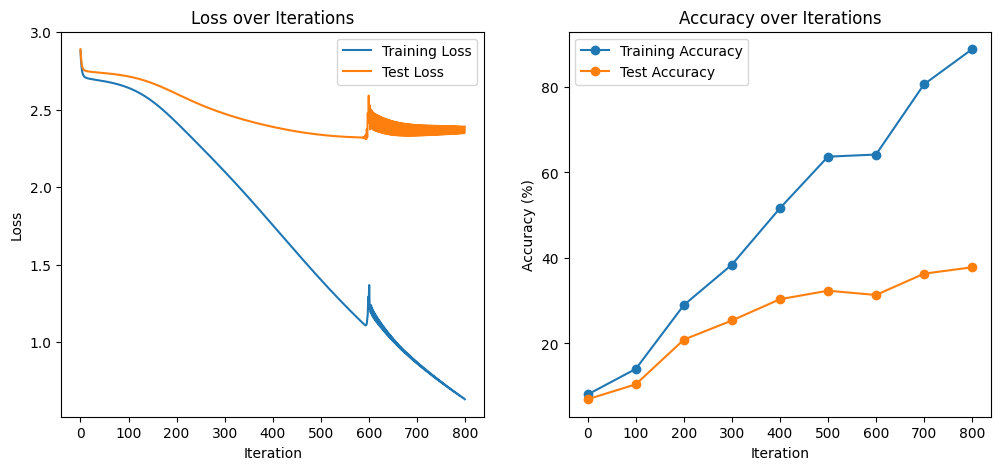

Early stopping triggered at iteration 800 (no improvement for 3 intervals).


In [ ]:


def compute_accuracy(A2, Y):
    predictions = np.argmax(A2, axis=0)
    labels = np.argmax(Y, axis=1)
    accuracy = np.mean(predictions == labels) * 100
    return accuracy

# -------------------------------
# 6. Train the Network
# -------------------------------

# Hyperparameters - adjust as you like
hidden_size = 128
output_size = len(types_list) # 18 classes
num_iterations = 3000 # hard limit so it doesn't go forever
learning_rate = 0.1


def model(X_train, Y_train, X_test, Y_test, hidden_size, output_size,
          num_iterations, learning_rate, early_stopping_patience=3):
    """
    Trains the neural network with early stopping and updates a single output containing both:
      - A log of training progress (loss and accuracy) that accumulates over time.
      - A figure with two subplots: one for loss curves and one for accuracy curves.

    Early stopping monitors the test loss and stops training if it does not improve
    for a number of updates defined by early_stopping_patience.

    This function uses IPython.display.clear_output to replace the output on each update,
    but reprints all stored log messages so that it appears as if the logs are accumulating.
    """
    input_size = X_train.shape[1]
    W1, b1, W2, b2 = initialize_parameters(input_size, hidden_size, output_size)

    # Lists to store losses every iteration.
    train_losses = []
    test_losses = []

    # Lists to store accuracy values at each update (every 100 iterations).
    acc_iters = []      # iteration numbers
    train_accs = []     # training accuracies at update points
    test_accs = []      # test accuracies at update points

    # List to accumulate log messages.
    log_messages = []

    # Early stopping variables.
    best_test_loss = float('inf')
    no_improvement_count = 0  # counts the number of update intervals with no improvement

    for i in range(num_iterations):
        # Forward propagation on training set.
        Z1, A1, Z2, A2_train = forward_propagation(X_train, W1, b1, W2, b2)
        train_cost = compute_cost(A2_train, Y_train)
        train_losses.append(train_cost)

        # Forward propagation on test set.
        _, _, _, A2_test = forward_propagation(X_test, W1, b1, W2, b2)
        test_cost = compute_cost(A2_test, Y_test)
        test_losses.append(test_cost)

        # Backward propagation on training data.
        dW1, db1, dW2, db2 = backward_propagation(X_train, Y_train, Z1, A1, Z2, A2_train, W1, W2)
        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

        # Update log and plots every 100 iterations.
        if i % 100 == 0:
            # Compute accuracies.
            train_acc = compute_accuracy(A2_train, Y_train)
            test_acc = compute_accuracy(A2_test, Y_test)

            # Create a log message and store it.
            log_msg = (f"Iteration {i}: Train Cost = {train_cost:.4f}, Test Cost = {test_cost:.4f}, "
                       f"Train Acc = {train_acc:.2f}%, Test Acc = {test_acc:.2f}%")
            log_messages.append(log_msg)

            # Save the iteration and accuracy values.
            acc_iters.append(i)
            train_accs.append(train_acc)
            test_accs.append(test_acc)

            # Check for improvement in test loss for early stopping.
            if test_cost < best_test_loss:
                best_test_loss = test_cost
                no_improvement_count = 0  # reset the counter if improvement is seen
            else:
                no_improvement_count += 1  # no improvement at this update interval

            # Clear the output.
            clear_output(wait=True)

            # Reprint all accumulated log messages.
            for msg in log_messages:
                print(msg)

            # Create a figure with two subplots: one for loss, one for accuracy.
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

            # Plot loss curves.
            ax1.plot(train_losses, label="Training Loss")
            ax1.plot(test_losses, label="Test Loss")
            ax1.set_xlabel("Iteration")
            ax1.set_ylabel("Loss")
            ax1.set_title("Loss over Iterations")
            ax1.legend()

            # Plot accuracy curves.
            ax2.plot(acc_iters, train_accs, marker='o', label="Training Accuracy")
            ax2.plot(acc_iters, test_accs, marker='o', label="Test Accuracy")
            ax2.set_xlabel("Iteration")
            ax2.set_ylabel("Accuracy (%)")
            ax2.set_title("Accuracy over Iterations")
            ax2.legend()

            plt.show()

            # Check if early stopping should be triggered.
            if no_improvement_count >= early_stopping_patience:
                print(f"Early stopping triggered at iteration {i} (no improvement for {early_stopping_patience} intervals).")
                break

    # Final display after training.
    plt.show()
    return W1, b1, W2, b2

# Call to the training function:
W1, b1, W2, b2 = model(X_train, y_train, X_test, y_test,
                        hidden_size, output_size, num_iterations, learning_rate,
                        early_stopping_patience=3)

# Visualising Model Predictions
This section **tests the trained model** by predicting Pokémon types on unseen test images and visualising the results.

#### **Key Steps:**
1. **Prediction Function (`predict`)**:
   - Uses the trained neural network to predict the Pokémon type with the highest probability.

2. **Select Random Test Samples**:
   - Randomly picks **9 Pokémon images** from the test set.

3. **Make Predictions**:
   - The model predicts the **primary type** for each selected Pokémon.

4. **Map Predictions to Type Names**:
   - Converts predicted indices back to their corresponding **Pokémon types** using a dictionary.

5. **Display Results in a 3x3 Grid**:
   - **Shows Pokémon images** with their **true type, predicted type, and name**.

If predictions **do not match the true types**, the model might need **more training** or **hyperparameter tuning**. This visualisation helps assess **how well the model generalizes to unseen Pokémon images!**

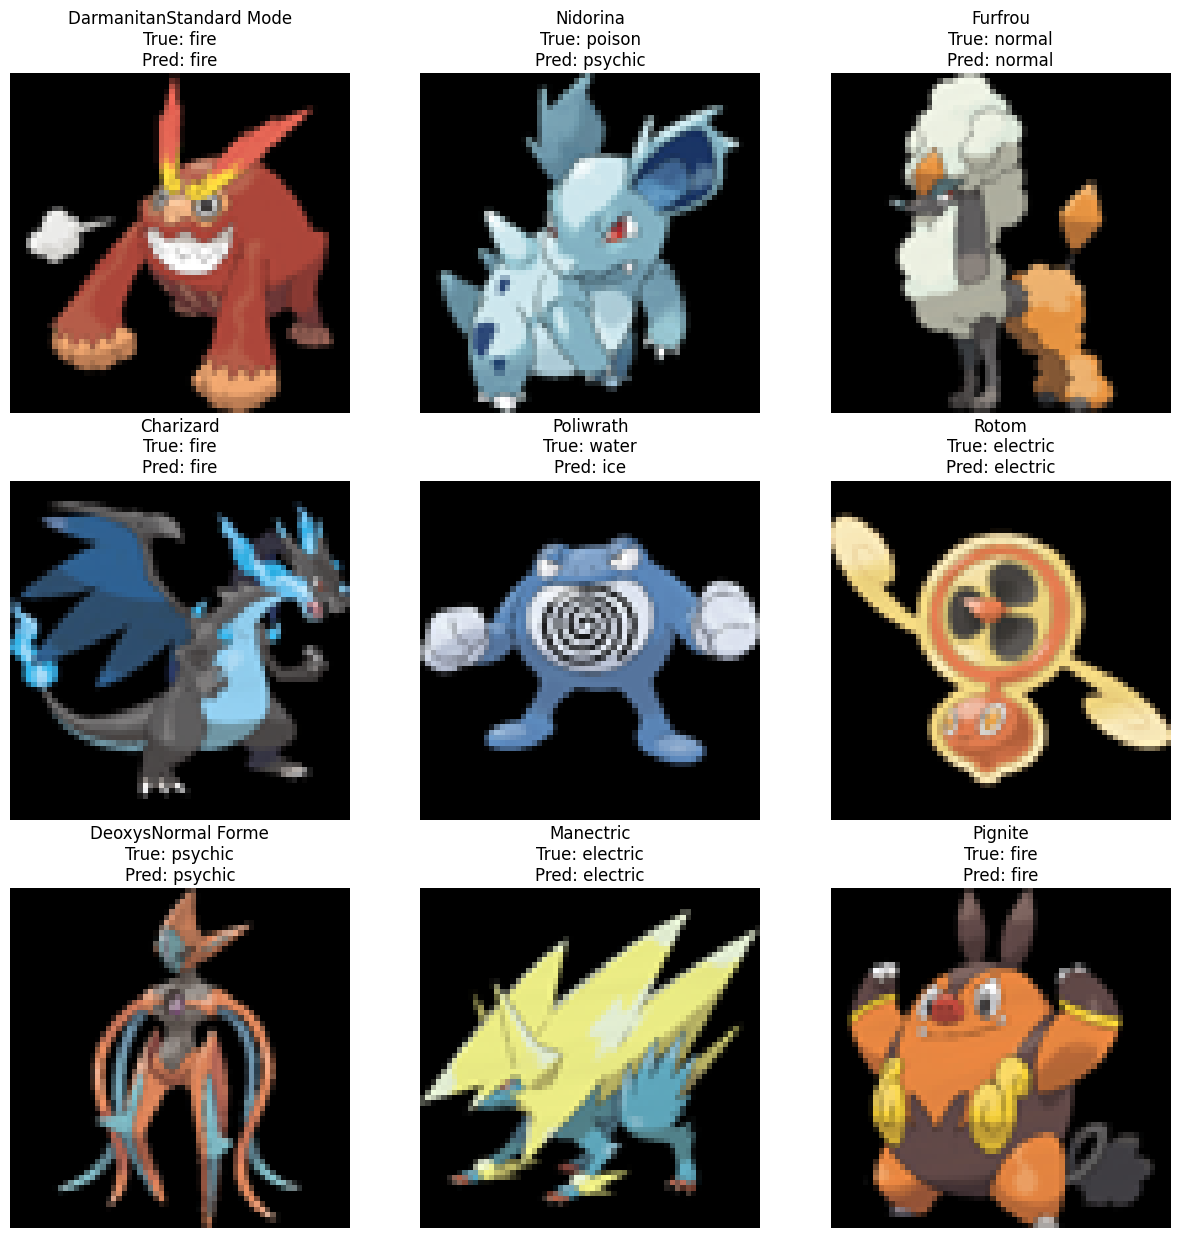

In [ ]:
# -------------------------------
# 7. Visualize Some Predictions with Pokémon Names
# -------------------------------
def predict(X, W1, b1, W2, b2):
    # Compute the output probabilities and return the index with the highest probability.
    _, _, _, A2 = forward_propagation(X, W1, b1, W2, b2)
    return np.argmax(A2, axis=0)

# Pick a few random test samples.
indices = np.random.choice(X_test.shape[0], 9, replace=False)
sample_images = X_test[indices]
sample_labels = y_test[indices]
sample_names = names_test[indices]  # Using the names from the test set

pred_indices = predict(sample_images, W1, b1, W2, b2)

# Create reverse mapping from index to type string.
index_to_type = {i: tp for tp, i in type_to_index.items()}

# Create a 3x3 grid for plotting.
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Flatten the axes array to iterate over it easily.
for i, ax in enumerate(axes.ravel()):
    # Reshape the flattened image back to (64, 64, 3)
    img = sample_images[i].reshape(IMG_SIZE[0], IMG_SIZE[1], 3)

    # Get the true type and predicted type.
    true_type = index_to_type[np.argmax(sample_labels[i])]
    pred_type = index_to_type[pred_indices[i]]

    # Get the Pokémon name.
    pokemon_name = sample_names[i]

    # Display the image with a title that includes the name, true type, and predicted type.
    ax.imshow(img)
    ax.set_title(f"{pokemon_name}\nTrue: {true_type}\nPred: {pred_type}")
    ax.axis('off')

plt.show()
